<a href="https://colab.research.google.com/github/rahafabumwise/instacart-ml-project/blob/main/notebooks/step_by_step_Decision_Tree_classification_tsk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

Mounted at /content/drive


In [1]:
import pandas as pd
clf_data = pd.read_parquet("/content/drive/MyDrive/instacart_project/data/classification/clf_df.parquet")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/instacart_project/data/classification/clf_df.parquet'

In [ ]:
clf_data.head()

,user_id,product_id,prior_purchase_count_uxp,days_since_last,reorder_prob_userxprod,user_total_orders,user_average_basket,user_reorder_ratio,user_mean_days_between_order,user_last_interorder_gap,product_total_purchase,product_reorder_ratio,product_avg_cart_pos,product_pop_overtime,reorder,streak,last_order_contains_product
0,202279,33120,5,0.0,0.800000,8,11.25,0.477778,21.862499,30.0,19400,0.708454,6.816959,18.204227,1,1,1
1,202279,28985,5,54.0,0.800000,8,11.25,0.477778,21.862499,30.0,67449,0.694465,7.501683,15.959421,0,0,0
2,202279,9327,1,123.0,0.000000,8,11.25,0.477778,21.862499,30.0,6299,0.157962,9.943166,14.909350,0,0,0
3,202279,45918,5,30.0,0.800000,8,11.25,0.477778,21.862499,30.0,744,0.272849,8.444893,17.795698,0,0,0
4,202279,30035,3,30.0,0.666667,8,11.25,0.477778,21.862499,30.0,569,0.507909,8.481546,19.773287,0,0,0


#Split data

In [ ]:
user_label = clf_data.groupby("user_id")["reorder"].max().astype(int)

In [ ]:
from sklearn.model_selection import train_test_split

users = user_label.index.to_numpy()
y_user = user_label.to_numpy()

train_users, test_users = train_test_split(
    users,
    test_size=0.2,
    random_state=42,
    stratify=y_user
)

In [ ]:
cl_train_df = clf_data[clf_data["user_id"].isin(train_users)].copy()
cl_test_df  = clf_data[clf_data["user_id"].isin(test_users)].copy()

In [ ]:
# 1) No overlap in users
assert set(cl_train_df["user_id"]).isdisjoint(set(cl_test_df["user_id"]))

# 2) Distribution check (row-level)
print("Row reorder rate - train:", cl_train_df["reorder"].mean())
print("Row reorder rate - test :", cl_test_df["reorder"].mean())

# 3) Distribution check (user-level)
print("User reorder rate - train:", user_label.loc[train_users].mean())
print("User reorder rate - test :", user_label.loc[test_users].mean())

Row reorder rate - train: 0.06228055421132008
Row reorder rate - test : 0.062279545787892056
User reorder rate - train: 0.5945734601465748
User reorder rate - test : 0.594588041317104


now another split for train data for more friendly ram work


In [ ]:
user_label = cl_train_df.groupby("user_id")["reorder"].max().astype(int)
from sklearn.model_selection import train_test_split

users = user_label.index.to_numpy()
y_user = user_label.to_numpy()

sample, _= train_test_split(
    users,
    train_size=0.1,
    random_state=42,
    stratify=y_user
)

In [ ]:
sample_df = cl_train_df[cl_train_df["user_id"].isin(sample)].copy()

In [ ]:
sample_df.shape

(1071950, 17)

In [ ]:
sample_df.head()

,user_id,product_id,prior_purchase_count_uxp,days_since_last,reorder_prob_userxprod,user_total_orders,user_average_basket,user_reorder_ratio,user_mean_days_between_order,user_last_interorder_gap,product_total_purchase,product_reorder_ratio,product_avg_cart_pos,product_pop_overtime,reorder,streak,last_order_contains_product
216,193635,40078,1,48.0,0.0,26,6.730769,0.52,7.362069,8.0,3573,0.492583,10.029107,17.527569,0,0,0
217,193635,9065,2,21.0,0.5,26,6.730769,0.52,7.362069,8.0,1944,0.448560,8.731996,14.029321,0,0,0
218,193635,46175,2,21.0,0.5,26,6.730769,0.52,7.362069,8.0,5928,0.447031,8.429150,12.042004,0,0,0
342,39630,20915,1,0.0,0.0,14,7.142857,0.19,4.258065,4.0,743,0.627187,7.717362,13.932705,0,1,1
343,39630,21949,1,0.0,0.0,14,7.142857,0.19,4.258065,4.0,1531,0.602874,10.124755,19.412149,0,1,1


In [ ]:
print("sample_df shape:", sample_df.shape)
print("unique users in sample_df:", sample_df["user_id"].nunique())
print("expected users in sample:", len(sample))

# sanity: every sampled user exists in sample_df
missing = set(sample) - set(sample_df["user_id"].unique())
print("missing sampled users:", len(missing))

sample_df shape: (1071950, 17)
unique users in sample_df: 16496
expected users in sample: 16496
missing sampled users: 0


#Step1 - Baseline model

In [ ]:
TARGET = "reorder"
GROUP  = "user_id"

y_sample = sample_df[TARGET].astype(int)
groups = sample_df[GROUP]

X_sample = sample_df.drop(["user_id", "product_id", TARGET], axis=1)

print("X:", X_sample.shape, "y:", y_sample.shape, "groups:", groups.nunique())
print("positive rate:", y_sample.mean())

X: (1071950, 14) y: (1071950,) groups: 16496
positive rate: 0.061565371519193994


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_baseline = DecisionTreeClassifier(random_state=42)


In [ ]:
from sklearn.model_selection import GroupKFold
import numpy as np
def get_oof_proba(model, X, y, groups, n_splits=3):
    gkf = GroupKFold(n_splits=n_splits)
    oof = np.zeros(len(y), dtype=float)

    for tr_idx, va_idx in gkf.split(X, y, groups):
        model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        oof[va_idx] = model.predict_proba(X.iloc[va_idx])[:, 1]

    return oof

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score
oof_lgbm = get_oof_proba(
    dt_baseline,
    X_sample,
    y_sample,
    groups,
    n_splits=3
)

print("dt baseline AUC:", roc_auc_score(y_sample, oof_lgbm))
print("dt baseline AP :", average_precision_score(y_sample, oof_lgbm))

dt baseline AUC: 0.5623016663852222
dt baseline AP : 0.0801913506775843


Decision Tree (default baseline, sample OOF GroupKFold by user):
The default Decision Tree achieved AUC ≈ 0.56 and AP ≈ 0.08, only slightly above the random baseline (AP close to the positive rate ~0.06). This indicates limited ability to rank reordered items above non-reordered items. The result is expected due to strong class imbalance and the high-variance nature of a single unconstrained tree under user-grouped validation.

#Step2 - handle imbalance

In [ ]:
dt_balanced = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score
oof_lgbm = get_oof_proba(
    dt_balanced,
    X_sample,
    y_sample,
    groups,
    n_splits=3
)

print("dt balanced AUC:", roc_auc_score(y_sample, oof_lgbm))
print("dt balanced AP :", average_precision_score(y_sample, oof_lgbm))

dt balanced AUC: 0.5515135933588818
dt balanced AP : 0.07711075461139509


On the unregularized (default) Decision Tree, enabling class_weight="balanced" did not improve OOF AUC/AP and slightly reduced them. However, because an unconstrained tree is high-variance and prone to overfitting, this result is not sufficient to decide whether class weighting is beneficial. We therefore regularize the tree first and then re-evaluate class weighting under the best regularized configuration.

#Step3 - GridSearch

In [ ]:
from sklearn.model_selection import GroupKFold, GridSearchCV

gkf = GroupKFold(n_splits=3)


In [ ]:
param_grid = {
    "max_depth": [3, 5, 7, 9],
    "min_samples_leaf": [1, 50, 200],
    "min_samples_split": [2, 200],
}
scoring = {
    "AP": "average_precision",
    "AUC": "roc_auc"
}



In [ ]:
grid = GridSearchCV(
    estimator=dt_baseline,
    param_grid=param_grid,
    scoring=scoring,
    refit="AP",
    cv=gkf.split(X_sample, y_sample, groups=groups),
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid.fit(X_sample, y_sample)


Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=<generator object _BaseKFold.split at 0x7b008e185140>,
             estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, 9],
                         'min_samples_leaf': [1, 50, 200],
                         'min_samples_split': [2, 200]},
             refit='AP', return_train_score=True,
             scoring={'AP': 'average_precision', 'AUC': 'roc_auc'}, verbose=2)

In [ ]:
print("Best params:", grid.best_params_)
print("Best CV AP :", grid.best_score_)


Best params: {'max_depth': 9, 'min_samples_leaf': 200, 'min_samples_split': 2}
Best CV AP : 0.2414622561923064


In [ ]:
import pandas as pd
res = pd.DataFrame(grid.cv_results_)

res[["mean_test_AP","mean_test_AUC","std_test_AP","params"]]\
  .sort_values("mean_test_AP", ascending=False)\
  .head(10)


,mean_test_AP,mean_test_AUC,std_test_AP,params
22,0.241462,0.806517,0.003583,"{'max_depth': 9, 'min_samples_leaf': 200, 'min..."
23,0.241462,0.806517,0.003583,"{'max_depth': 9, 'min_samples_leaf': 200, 'min..."
21,0.239435,0.805957,0.002571,"{'max_depth': 9, 'min_samples_leaf': 50, 'min_..."
16,0.239170,0.804651,0.003826,"{'max_depth': 7, 'min_samples_leaf': 200, 'min..."
17,0.239170,0.804651,0.003826,"{'max_depth': 7, 'min_samples_leaf': 200, 'min..."
15,0.238499,0.804532,0.003699,"{'max_depth': 7, 'min_samples_leaf': 50, 'min_..."
19,0.238419,0.806493,0.003074,"{'max_depth': 9, 'min_samples_leaf': 1, 'min_s..."
20,0.238386,0.805408,0.002940,"{'max_depth': 9, 'min_samples_leaf': 50, 'min_..."
14,0.238139,0.804454,0.003897,"{'max_depth': 7, 'min_samples_leaf': 50, 'min_..."
13,0.237741,0.804372,0.003773,"{'max_depth': 7, 'min_samples_leaf': 1, 'min_s..."


Decision Tree – Regularization Results (Sample, GroupKFold):
The default Decision Tree showed weak performance under user-grouped validation, indicating strong overfitting and limited ranking ability. After applying a small GridSearch with GroupKFold and selecting by Average Precision, a regularized configuration (max_depth=9, min_samples_leaf=200, min_samples_split = 2) substantially improved both AP and AUC and produced stable cross-validation results. This confirms that regularization is essential for Decision Trees in this setting.

## Balanced vs Unweighted Decision Tree

In [ ]:
best_params = {'max_depth': 9, 'min_samples_leaf': 200, 'min_samples_split': 2}

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, f1_score
import numpy as np

dt_unweighted = DecisionTreeClassifier(random_state=42, **best_params)

oof_unweighted = get_oof_proba(dt_unweighted, X_sample, y_sample, groups, n_splits=3)

print("DT unweighted OOF AUC:", roc_auc_score(y_sample, oof_unweighted))
print("DT unweighted OOF AP :", average_precision_score(y_sample, oof_unweighted))


DT unweighted OOF AUC: 0.8066369149546107
DT unweighted OOF AP : 0.2424579049974169


In [ ]:
dt_balanced = DecisionTreeClassifier(random_state=42, class_weight="balanced", **best_params)

oof_balanced = get_oof_proba(dt_balanced, X_sample, y_sample, groups, n_splits=3)

print("\nDT balanced OOF AUC:", roc_auc_score(y_sample, oof_balanced))
print("DT balanced OOF AP :", average_precision_score(y_sample, oof_balanced))



DT balanced OOF AUC: 0.8057414633323519
DT balanced OOF AP : 0.24370606004334178


In [ ]:
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

compare = pd.DataFrame([
    ["DT_unweighted", roc_auc_score(y_sample, oof_unweighted), average_precision_score(y_sample, oof_unweighted)],
    ["DT_balanced",   roc_auc_score(y_sample, oof_balanced),   average_precision_score(y_sample, oof_balanced)]
], columns=["model", "OOF_AUC", "OOF_AP"])

compare


,model,OOF_AUC,OOF_AP
0,DT_unweighted,0.806637,0.242458
1,DT_balanced,0.805741,0.243706


The default Decision Tree performed poorly under user-grouped validation, indicating strong overfitting and limited ranking ability. A small GridSearch with GroupKFold identified a regularized configuration (max_depth=9, min_samples_leaf=200, min_samples_split=2) that substantially improved performance to OOF AUC ≈ 0.806 and OOF AP ≈ 0.244 on the development sample. We compared unweighted vs class_weight="balanced" under the same regularization and observed a small AP improvement with balanced weighting while AUC remained effectively unchanged. Therefore, we retain the balanced regularized tree for the final Decision Tree comparison.

#Step4-Full-Train OOF Metrics and Operating Threshold

In [ ]:
TARGET = "reorder"
GROUP  = "user_id"

X_train = cl_train_df.drop([GROUP, "product_id", TARGET], axis=1)
y_train = cl_train_df[TARGET].astype(int)
groups_train = cl_train_df[GROUP]

X_test = cl_test_df.drop([GROUP, "product_id", TARGET], axis=1)
y_test = cl_test_df[TARGET].astype(int)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_final = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=9,
    min_samples_leaf=200,
    min_samples_split=2
)


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

oof_dt = get_oof_proba(dt_final, X_train, y_train, groups_train, n_splits=3)

print("DT FULL-TRAIN OOF AUC:", roc_auc_score(y_train, oof_dt))
print("DT FULL-TRAIN OOF AP :", average_precision_score(y_train, oof_dt))


DT FULL-TRAIN OOF AUC: 0.8114782053395428
DT FULL-TRAIN OOF AP : 0.25152258892341245


In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_train, oof_dt)

f1_scores = 2 * precision * recall / (precision + recall + 1e-12)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx - 1] if best_idx > 0 else 0.5

best_f1 = f1_score(y_train, (oof_dt >= best_threshold).astype(int))

print("Best threshold (from TRAIN OOF):", best_threshold)
print("OOF TRAIN F1:", best_f1)


Best threshold (from TRAIN OOF): 0.7456057845589842
OOF TRAIN F1: 0.3258716382629211


In [ ]:
from sklearn.metrics import precision_score, recall_score

pred_oof = (oof_dt >= 0.7456057845589842).astype(int)

print("Predicted positive rate:", pred_oof.mean())
print("OOF Precision:", precision_score(y_train, pred_oof))
print("OOF Recall   :", recall_score(y_train, pred_oof))


Predicted positive rate: 0.10085903694272304
OOF Precision: 0.26354884721485955
OOF Recall   : 0.42679907483264157


Using the finalized regularized Decision Tree, we performed GroupKFold (by user) on the full training set to obtain out-of-fold (OOF) predictions, ensuring validation without leakage. The model achieved OOF AUC ≈ 0.811 and OOF AP ≈ 0.252, indicating strong ranking performance under unseen-user validation. We then selected an F1-optimal threshold from the OOF scores (≈ 0.746), yielding a balanced operating point with ~10% predicted positives, precision ≈ 0.264, and recall ≈ 0.427. This configuration is now fixed and will be used for the final train-on-full → predict-on-test evaluation and feature importance reporting.

#Step 5-fit on full train → predict on test

the model we choose

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_final = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=9,
    min_samples_leaf=200,
    min_samples_split=2
)
thr_dt = 0.745


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

dt_final.fit(X_train, y_train)

test_scores_dt = dt_final.predict_proba(X_test)[:, 1]

print("DT TEST AUC:", roc_auc_score(y_test, test_scores_dt))
print("DT TEST AP :", average_precision_score(y_test, test_scores_dt))


DT TEST AUC: 0.8135368408547836
DT TEST AP : 0.2532762991417745


In [ ]:
test_pred_dt = (test_scores_dt >= thr_dt).astype(int)

print("DT TEST F1 (OOF threshold):", f1_score(y_test, test_pred_dt))

DT TEST F1 (OOF threshold): 0.32837108461231246


The final regularized Decision Tree was trained on the full training set and evaluated on the held-out test users. It achieved AUC = 0.814 and AP = 0.253, closely matching the full-train OOF validation scores, indicating strong generalization and no evidence of overfitting. Using the F1-optimal threshold selected from training OOF predictions (≈0.745), the model obtained test F1 ≈ 0.328. These results establish the Decision Tree as a strong non-linear comparison model.

#plots

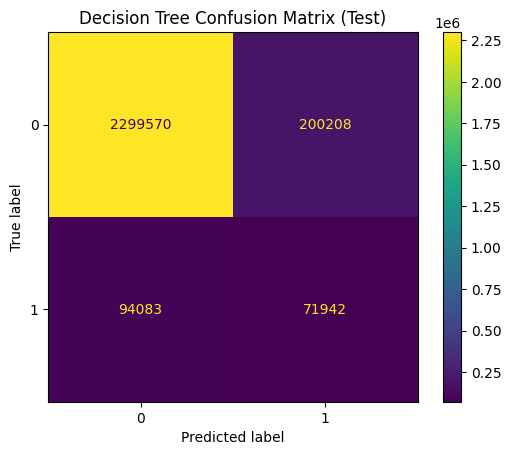

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, test_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Decision Tree Confusion Matrix (Test)")
plt.show()

At the OOF-selected threshold (≈0.745), the model correctly classifies most non-reordered items (≈2.30M true negatives) while predicting reorders for a smaller subset of cases. Around 71,942 true reorders are correctly identified, while 94,083 reorders are missed, reflecting the difficulty of the task under strong class imbalance. The number of false positives (≈200k) shows the cost of recovering positives while keeping precision reasonable.

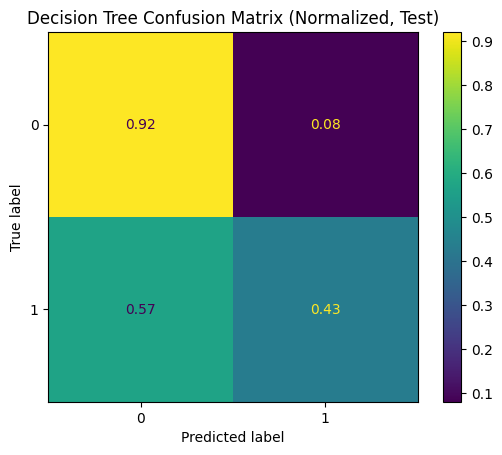

In [ ]:
cm_norm = confusion_matrix(y_test, test_pred_dt, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp.plot(values_format=".2f")
plt.title("Decision Tree Confusion Matrix (Normalized, Test)")
plt.show()

The normalized confusion matrix highlights that the model achieves ~92% specificity for non-reordered items, meaning it effectively avoids false alarms. For reordered items, the model reaches ~43% recall, indicating that nearly half of true reorders are successfully detected. This confirms that the chosen threshold prioritizes a balanced precision–recall tradeoff rather than aggressive positive prediction.

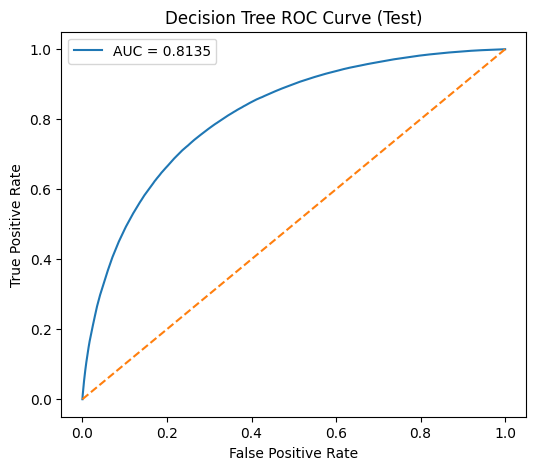

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, test_scores_dt)
auc = roc_auc_score(y_test, test_scores_dt)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve (Test)")
plt.legend()
plt.show()


The ROC curve demonstrates strong ranking performance across thresholds, with a test AUC ≈ 0.814. This indicates that the model consistently assigns higher scores to reordered items than to non-reordered ones, regardless of the chosen decision threshold. The clear separation from the diagonal baseline confirms meaningful discriminatory power

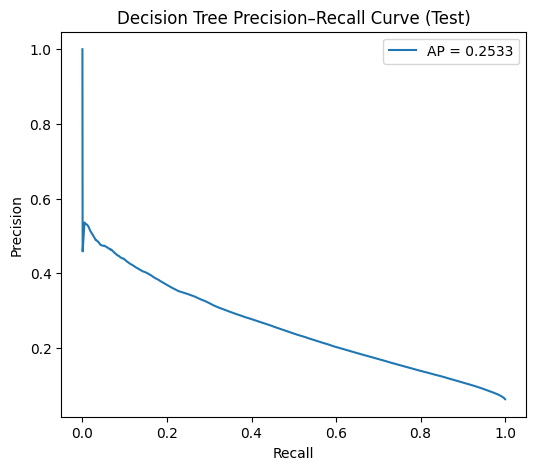

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

prec, rec, _ = precision_recall_curve(y_test, test_scores_dt)
ap = average_precision_score(y_test, test_scores_dt)

plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Decision Tree Precision–Recall Curve (Test)")
plt.legend()
plt.show()


The Precision–Recall curve shows performance on the positive (reorder) class, which is critical given the low base rate (~6%). The Average Precision ≈ 0.253 represents a substantial improvement over random ranking and indicates that reordered items are concentrated toward the top of the model’s predictions. As recall increases, precision declines smoothly, which is expected in rare-event prediction.

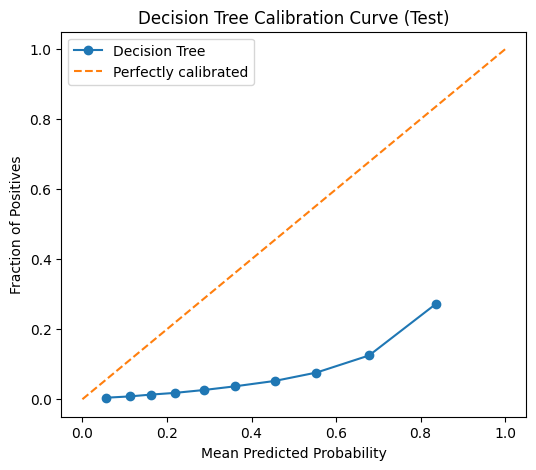

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, test_scores_dt, n_bins=10, strategy="quantile")

plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker="o", label="Decision Tree")
plt.plot([0,1], [0,1], linestyle="--", label="Perfectly calibrated")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Decision Tree Calibration Curve (Test)")
plt.legend()
plt.show()


The calibration curve shows that predicted probabilities are generally higher than the observed fraction of reorders, indicating poor probability calibration. This behavior is expected for a single Decision Tree, where probabilities are derived from leaf class proportions rather than optimized likelihoods. As a result, the model is better suited for ranking and threshold-based decisions than for producing well-calibrated probabilities

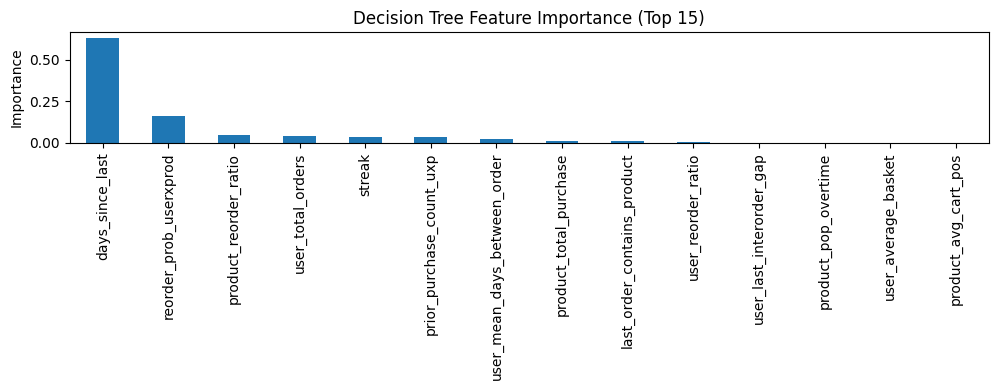

In [ ]:
import pandas as pd

imp = pd.Series(dt_final.feature_importances_, index=X_train.columns).sort_values(ascending=False)
topk = imp.head(15)

ax = topk.plot(kind="bar", figsize=(10,4))
plt.title("Decision Tree Feature Importance (Top 15)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


Feature importance reveals that days_since_last is by far the most influential feature, highlighting the dominant role of recency in reorder behavior. User–product interaction features such as reorder_prob_userxprod, prior_purchase_count_uxp, and streak-related variables also contribute strongly, confirming that personalized purchase history is critical for prediction. Less importance is assigned to global product or user aggregates, suggesting that fine-grained interaction features drive most decisions.

#Final Conclusion — Decision Tree classifier

We first evaluated a baseline Decision Tree with default parameters, which showed weak performance under user-grouped validation, confirming strong overfitting and limited ranking ability in the presence of severe class imbalance. To address this, we applied regularization through a small GridSearch using GroupKFold by user, focusing on depth and leaf constraints. This substantially improved performance, demonstrating that controlling model complexity is essential for single trees in this setting.

After identifying the best regularized configuration, we compared unweighted and class-weighted training. The balanced version produced a very small improvement in Average Precision, while AUC remained effectively unchanged. Given the imbalanced nature of the task and the negligible difference between the two variants, the balanced regularized tree was retained as the final Decision Tree model.

When evaluated on the full training set using out-of-fold predictions and then on the held-out test set, the Decision Tree achieved AUC ≈ 0.81 and AP ≈ 0.25, closely matching its validation results and indicating good generalization. However, despite capturing non-linear patterns, the Decision Tree did not outperform Logistic Regression, and its performance remained slightly below that of LightGBM.

Overall, the results show that all three models—Logistic Regression, Decision Tree, and LightGBM—perform very similarly, with only small and consistent differences. This suggests that feature engineering and validation strategy had a larger impact than model choice, and that the task is largely driven by strong linear and monotonic signals (such as recency and user–product affinity). LightGBM provides a modest but consistent improvement by aggregating many trees, while the single Decision Tree remains a competitive but limited non-linear baseline.